# Warehouse location and fleet forecasting

Workflow:
1. Extract data from the file with options
2. Plot a delivery point graph
3. Divide the delivery point into clusters (number of vehicles). Justify the choice of the number of vehicles
4. Analyze the initial partitioning into clusters in terms of vehicle capacity utilization
5. If necessary, exchange nodes between clusters and/or create new clusters
6. Analyze the result of the new partitioning
7. Solve traveling salesman problems for each cluster using a genetic algorithm
8. Analyze the resulting routes
9. Analyze transport utilization characteristics

## 1. Import libraries and data

In [1]:
import pandas as pd
from pandas import read_csv
import numpy as np
from matplotlib import pyplot as plt
import seaborn as sns
from sklearn.cluster import KMeans
from sklearn.datasets import make_blobs


In [7]:
data = read_csv('Retail_stores.csv', header = 0, index_col= 0)

## 2. Acquaintance with data

In [8]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       200 non-null    float64
 1   Y       200 non-null    float64
 2   Demand  0 non-null      float64
 3   demand  200 non-null    int64  
dtypes: float64(3), int64(1)
memory usage: 6.4 KB


In [9]:
del data['Demand']
data

,X,Y,demand
0,-10.564807,-8.261978,223
1,-14.391704,16.716745,337
2,1.675834,3.174182,216
3,11.187684,11.774094,97
4,6.833063,10.857710,351
...,...,...,...
195,-17.998140,14.449818,358
196,12.160333,4.299443,375
197,-13.561926,-6.276303,52
198,2.735801,-4.310057,251


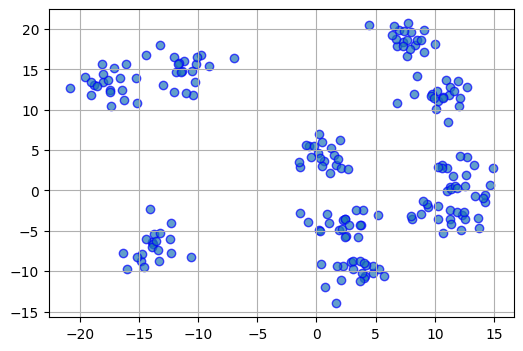

In [13]:
plt.figure(figsize=(6, 4))
plt.scatter(data.iloc[:,0], data.iloc[:,1], alpha=0.7, edgecolors='b')
plt.grid(True)
plt.show()

## 3. Clustering and Logistics Calculations

Capacity of a truck is 3000kg